<h1 align="center"> Initial Plots </h1>

<br>
<i> Import necessary libraries: <i>

In [1]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis 
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import math
from matplotlib.patches import Ellipse
import time
import random
from sklearn.preprocessing import StandardScaler
np.random.seed(2)

import os

### Matching Samples for Analysis

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

In [3]:
# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

In [4]:
# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

In [5]:
# Check length of both sample dataframes
print("Number of rows in RNA samples:", df_merged.shape[0])
print("Number of rows in radiomics samples:", df_merged2.shape[0])

Number of rows in RNA samples: 36
Number of rows in radiomics samples: 36


### Filter Images and RNA Data

In [6]:
# Filter radiomics data 
rad_cols = df_merged2.drop(["Extraction site", "SURGICAL", "CASE ID", "CASE ID2", "MAHCINE_CORECCTED"], axis=1)

In [7]:
# Step 1: Prepare image filenames and filter data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
rna_data_filtered = []
rad_data_filtered = []
surgical_rna = []
surgical_rad = []
sample_count_rna = 0 
sample_count_rad = 0 

In [8]:
for index, row in df_merged.iterrows():

    case_id = str(row['CASE ID']).strip() if pd.notna(row['CASE ID']) else ''
    case_id2 = str(row['CASE ID2']).strip() if pd.notna(row['CASE ID2']) else ''

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            if case_id in file_name or case_id2 in file_name:
                rna_data_filtered.append(row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0))
                surgical_rna.append(row["SURGICAL"])
                sample_count_rna += 1
                break

print(f"Number of Samples: ", sample_count_rna)

Number of Samples:  31


In [9]:
for index, row in df_merged2.iterrows():

    case_id = str(row['CASE ID']).strip() if pd.notna(row['CASE ID']) else ''
    case_id2 = str(row['CASE ID2']).strip() if pd.notna(row['CASE ID2']) else ''

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            if case_id in file_name or case_id2 in file_name:
                rad_data_filtered.append(row[rad_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0))
                surgical_rad.append(row["SURGICAL"])
                sample_count_rad += 1
                break

print(f"Number of Samples: ", sample_count_rad)

Number of Samples:  31


In [10]:
flag = (surgical_rna == surgical_rad)
print(f"Matching Diagnoses: ", flag)

Matching Diagnoses:  True


### Radiomics Tabular Data

In [11]:
# Convert to DataFrame
rad_data_filtered = pd.DataFrame(rad_data_filtered)
# Scale radiomics sample counts
scaler = StandardScaler()
rad_df = pd.DataFrame(scaler.fit_transform(rad_data_filtered), columns=rad_data_filtered.columns)
rad_df.insert(0, "SURGICAL", surgical_rad)

In [12]:
rad_df

,SURGICAL,N.voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,...,GLCM_sumVar_HHH_256gl,GLCM_sumEnt_HHH_256gl,GLCM_difVar_HHH_256gl,GLCM_difEnt_HHH_256gl,GLCM_AutoCorrel_HHH_256gl,GLCM_ClTend_HHH_256gl,GLCM_Homoge1_HHH_256gl,GLCM_IDMN_HHH_256gl,GLCM_IDN_HHH_256gl,GLCM_invVar_HHH_256gl
0,B-S,0.471087,0.471087,0.482484,0.379178,-0.630836,0.619221,0.571787,-0.507670,-0.144641,...,-0.550146,-0.060563,-0.389179,-0.113917,-1.085655,-0.550146,-0.193038,0.498820,0.414751,0.376349
1,M-S,-0.192717,-0.192717,-0.184456,0.504596,-0.109435,-0.037652,-0.073553,-0.208806,-0.148282,...,-0.107306,-0.132372,0.040455,-0.160019,1.416691,-0.107306,0.112091,0.036799,0.225269,0.515695
2,M-S,-0.989050,-0.989050,-0.997508,-0.776639,0.747215,-0.979556,-0.918136,0.356596,-0.821862,...,-0.939975,-0.475393,-0.838208,-0.462619,-1.337800,-0.939975,-0.197755,0.903436,0.763029,0.300425
3,M-S,-0.447188,-0.447188,-0.440917,0.472973,0.057944,-0.273164,-0.300617,-0.126803,-1.105858,...,0.949934,1.107053,0.004648,0.960272,-1.612511,0.949934,-1.139334,-0.614972,-1.186780,-1.001205
4,M-S,0.574093,0.574093,0.571509,-0.499879,-0.664645,0.669761,0.680658,-0.523800,0.357814,...,-0.535875,-0.112796,-0.819177,-0.339410,-1.720983,-0.535875,-0.203764,0.771437,0.581979,0.329336
5,M-S,-0.617721,-0.617721,-0.624117,-0.522135,0.489003,-0.618075,-0.576534,0.248220,-0.775440,...,-0.351317,-0.162260,-0.451074,-0.224067,-1.199991,-0.351317,0.335924,0.485856,0.432370,-0.063688
6,M-S,-0.490069,-0.490069,-0.487241,0.274048,0.145611,-0.352054,-0.363757,-0.060155,-0.658018,...,0.328598,0.456002,0.616660,0.454014,-1.292683,0.328598,-0.472508,-0.409811,-0.341205,-0.001381
7,M-S,0.903715,0.903715,0.931093,1.160796,-0.855228,0.986228,0.875468,-0.605164,0.590836,...,-0.635692,-0.183904,-0.423627,-0.076082,-0.516176,-0.635692,0.267376,0.485365,0.389763,0.081119
8,B-S,0.215111,0.215111,0.225324,0.453643,-0.460777,0.385165,0.340461,-0.419381,-0.170128,...,-0.760641,-0.305503,-0.679087,-0.223395,0.464921,-0.760641,0.641180,0.686658,0.541204,-0.135332
9,M-S,0.386914,0.386914,0.375519,-1.052662,-0.488152,0.450930,0.502997,-0.423665,-0.297562,...,0.191460,0.628190,0.099688,0.618299,0.551055,0.191460,-0.705996,-0.252181,-0.528326,-0.474946


### RNA Tabular Data

In [13]:
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)
# Scale RNA sample counts
scaler = StandardScaler()
rna_df = pd.DataFrame(scaler.fit_transform(rna_data_filtered), columns=rna_data_filtered.columns)
rna_df.insert(0, "SURGICAL", surgical_rna)

In [14]:
rna_df

1,SURGICAL,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,B-S,-0.501120,-0.555797,0.013826,0.0,0.731227,-0.182574,0.0,-0.233285,0.0,...,-0.662371,-0.384900,-0.182574,-0.461566,-0.866792,-0.786724,-0.294198,-0.262647,0.0,-0.733942
1,M-S,-0.501120,-0.178504,-0.414776,0.0,0.926286,-0.182574,0.0,-0.233285,0.0,...,-0.249759,-0.384900,-0.182574,1.582513,-0.227789,-0.042098,-0.086922,-0.446642,0.0,0.008475
2,M-S,-0.501120,0.019125,3.073846,0.0,0.449893,-0.182574,0.0,-0.233285,0.0,...,-0.712450,-0.384900,-0.182574,-0.461566,-0.576095,-0.966539,-0.708749,-0.729061,0.0,-0.610206
3,M-S,-0.501120,-0.268336,-0.145654,0.0,-0.262821,-0.182574,0.0,-0.233285,0.0,...,-0.562758,-0.384900,-0.182574,1.582513,0.095575,0.125311,0.327629,-0.169037,0.0,-0.796093
4,M-S,2.827748,-0.376134,-0.295166,0.0,-0.364101,5.477226,0.0,-0.233285,0.0,...,0.491969,2.598076,-0.182574,-0.461566,2.425405,1.595874,1.571283,0.721816,0.0,1.722136
5,M-S,2.272936,-0.286302,-1.052696,0.0,-0.244065,-0.182574,0.0,-0.233285,0.0,...,-0.799712,2.598076,5.477226,1.582513,0.414308,0.204383,0.120354,-0.621097,0.0,0.554270
6,M-S,-0.501120,0.450318,0.133436,0.0,-1.643235,-0.182574,0.0,-0.233285,0.0,...,-0.547545,-0.384900,-0.182574,-0.461566,-0.671529,-0.307346,-0.501473,-0.458996,0.0,-0.894403
7,M-S,-0.501120,4.510710,-0.275231,0.0,0.990055,-0.182574,0.0,-0.233285,0.0,...,-0.472487,-0.384900,-0.182574,-0.461566,-0.657129,-1.202067,-1.330575,-0.656816,0.0,-0.818693
8,B-S,-0.501120,-0.358168,0.821193,0.0,0.232328,-0.182574,0.0,-0.233285,0.0,...,-0.951365,-0.384900,-0.182574,-0.461566,-0.698283,-0.216692,-0.294198,-0.717061,0.0,-0.653146
9,M-S,-0.501120,-0.591730,-0.972956,0.0,0.888775,-0.182574,0.0,-0.233285,0.0,...,-0.425085,-0.384900,-0.182574,-0.461566,-0.130072,-0.288461,0.534905,-0.461779,0.0,-0.289283


### Radiomics - Principal Component Analysis (2 Components)

#### Run LDA on the Original Dataset to Select Features

In [15]:
# Divide the dataset into features (X) and target variable (y)
X = rad_df.drop(["SURGICAL"], axis=1)
y = rad_df[["SURGICAL"]]

# Fit the LDA model
model = LinearDiscriminantAnalysis()
model.fit(X, y)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearDiscriminantAnalysis()

In [16]:
# Print coefficient table
coef_table = pd.DataFrame(list(X.columns)).copy()
coef_table.insert(len(coef_table.columns), "Coefficients", model.coef_.transpose())
coef_table

,0,Coefficients
0,N.voxels,0.004478
1,SNS_vol,0.004478
2,SNS_area,0.004317
3,SNS_s2v,-0.010927
4,SNS_sph,0.002105
...,...,...
3901,GLCM_ClTend_HHH_256gl,-0.002197
3902,GLCM_Homoge1_HHH_256gl,0.000021
3903,GLCM_IDMN_HHH_256gl,-0.001609
3904,GLCM_IDN_HHH_256gl,0.000058


In [17]:
# Add absoloute coefficients column
coef_table["Absolute Coefficients"] = coef_table["Coefficients"].abs()
coef_table

,0,Coefficients,Absolute Coefficients
0,N.voxels,0.004478,0.004478
1,SNS_vol,0.004478,0.004478
2,SNS_area,0.004317,0.004317
3,SNS_s2v,-0.010927,0.010927
4,SNS_sph,0.002105,0.002105
...,...,...,...
3901,GLCM_ClTend_HHH_256gl,-0.002197,0.002197
3902,GLCM_Homoge1_HHH_256gl,0.000021,0.000021
3903,GLCM_IDMN_HHH_256gl,-0.001609,0.001609
3904,GLCM_IDN_HHH_256gl,0.000058,0.000058


In [18]:
# Sort absolute coefficients 
coef_table = coef_table.sort_values(by="Absolute Coefficients", ascending=False)
coef_table

,0,Coefficients,Absolute Coefficients
2716,FD_min_HLH_8gl,0.044497,0.044497
2283,FD_min_HLL_8gl,0.044497,0.044497
2610,FOS_Imode_HLH,0.040439,0.040439
2177,FOS_Imode_HLL,0.040439,0.040439
1537,FD_min_LHL_32gl,-0.033424,0.033424
...,...,...,...
58,FD_min_4gl,0.000000,0.000000
1790,FD_min_LHH_4gl,0.000000,0.000000
491,FD_min_LLL_4gl,0.000000,0.000000
3089,FD_min_HHL_4gl,0.000000,0.000000


In [19]:
# Store top 1000 features
top_1000_rad = coef_table[0].head(1000).to_list()

In [20]:
# Seperating out the features
rad_1000 = rad_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rad_1000 = rad_1000.loc[:, rad_1000.columns.isin(top_1000_rad)]
# Seperating out the target
rad_class = rad_df[["SURGICAL"]]

# Create PCA with 2 components
rad_pca = PCA(n_components=2)
rad_prinComps = rad_pca.fit_transform(rad_1000)

# Print DataFrame
df_rad_princComps = pd.DataFrame(data=rad_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rad_princComps

,Principal Component 1,Principal Component 2
0,-1.441324,2.665872
1,-3.260024,-1.935446
2,-11.170139,-1.262488
3,5.838780,1.451914
4,-3.644630,4.133375
5,4.807068,14.227055
6,21.817625,5.392702
7,-2.973771,-3.572685
8,-15.715112,-1.467488
9,13.543893,-7.624683


In [21]:
# Percentage explained by each component
print(rad_pca.explained_variance_ratio_)

[0.26139105 0.11516797]


In [22]:
# Final dataframe for plotting the data for class
df_rad_pca_class = pd.concat([df_rad_princComps, rad_class], axis=1)

In [23]:
# Function needed to create ellipses for PCA
def eigsorted(cov):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    return vals[order], vecs[:,order]

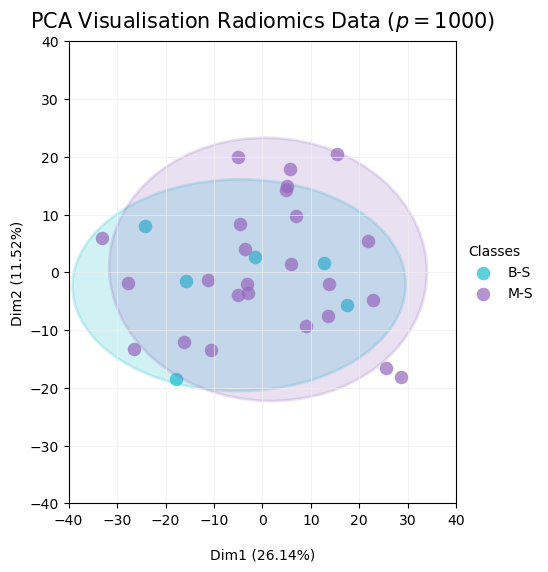

In [24]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rad_pca_class["SURGICAL"] == target
    xdata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rad_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation Radiomics Data ($p=1000$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-40,40)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rad_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-40,40)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

### RNA - Principal Component Analysis (2 Components)

#### Run LDA on the Original Dataset to Select Features

In [25]:
# Divide the dataset into features (X) and target variable (y)
X = rna_df.drop(["SURGICAL"], axis=1)
y = rna_df[["SURGICAL"]]

# Fit the LDA model
model = LinearDiscriminantAnalysis()
model.fit(X, y)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LinearDiscriminantAnalysis()

In [26]:
# Print coefficient table
coef_table = pd.DataFrame(list(X.columns)).copy()
coef_table.insert(len(coef_table.columns), "Coefficients", model.coef_.transpose())
coef_table

,0,Coefficients
0,ENSG00000279928,-1.820333e-04
1,ENSG00000228037,8.848121e-06
2,ENSG00000142611,1.741970e-04
3,ENSG00000284616,-3.574437e-17
4,ENSG00000157911,1.253005e-04
...,...,...
63182,ENSG00000198695,-1.434434e-04
63183,ENSG00000210194,-2.841784e-04
63184,ENSG00000198727,2.463716e-05
63185,ENSG00000210195,0.000000e+00


In [27]:
# Add absoloute coefficients column
coef_table["Absolute Coefficients"] = coef_table["Coefficients"].abs()
coef_table

,0,Coefficients,Absolute Coefficients
0,ENSG00000279928,-1.820333e-04,1.820333e-04
1,ENSG00000228037,8.848121e-06,8.848121e-06
2,ENSG00000142611,1.741970e-04,1.741970e-04
3,ENSG00000284616,-3.574437e-17,3.574437e-17
4,ENSG00000157911,1.253005e-04,1.253005e-04
...,...,...,...
63182,ENSG00000198695,-1.434434e-04,1.434434e-04
63183,ENSG00000210194,-2.841784e-04,2.841784e-04
63184,ENSG00000198727,2.463716e-05,2.463716e-05
63185,ENSG00000210195,0.000000e+00,0.000000e+00


In [28]:
# Sort absolute coefficients 
coef_table = coef_table.sort_values(by="Absolute Coefficients", ascending=False)
coef_table

,0,Coefficients,Absolute Coefficients
5466,ENSG00000198626,-0.001795,0.001795
21066,ENSG00000137252,-0.001606,0.001606
36331,ENSG00000280339,-0.001543,0.001543
4200,ENSG00000162494,-0.001523,0.001523
30299,ENSG00000104213,-0.001522,0.001522
...,...,...,...
49653,ENSG00000264722,0.000000,0.000000
49654,ENSG00000257366,0.000000,0.000000
49655,ENSG00000265373,0.000000,0.000000
17050,ENSG00000231585,0.000000,0.000000


In [29]:
# Store top 1000 features
top_1000_rna = coef_table[0].head(1000).to_list()

In [30]:
# Seperating out the features
rna_1000 = rna_df.drop(["SURGICAL"], axis=1)
# Only keep the top 1000 features
rna_1000 = rna_1000.loc[:, rna_1000.columns.isin(top_1000_rna)]
# Seperating out the target
rna_class = rna_df[["SURGICAL"]]

# Create PCA with 2 components
rna_pca = PCA(n_components=2)
rna_prinComps = rna_pca.fit_transform(rna_1000)

# Create DataFrame
df_rna_princComps = pd.DataFrame(data=rna_prinComps, columns=["Principal Component 1", "Principal Component 2"])
df_rna_princComps = df_rna_princComps.loc[:].mul(10).round(2)
df_rna_princComps

,Principal Component 1,Principal Component 2
0,423.72,-39.06
1,-161.85,-19.50
2,-127.30,-32.35
3,38.24,-28.45
4,-94.35,-10.43
5,-187.15,-18.83
6,-114.48,-15.20
7,-135.12,-26.76
8,95.01,681.45
9,-120.33,-10.89


In [31]:
# Percentage explained by each component
print(rna_pca.explained_variance_ratio_)

[0.39662119 0.15909938]


In [32]:
# Final dataframe for plotting the data for class
df_rna_pca_class = pd.concat([df_rna_princComps, rna_class], axis=1)

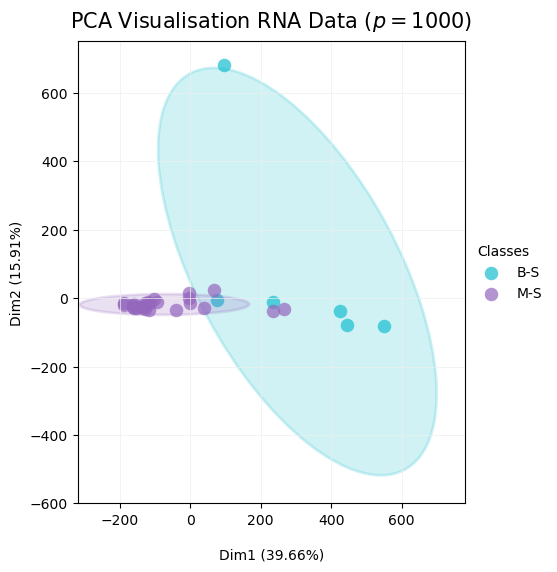

In [33]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_pca_class["SURGICAL"] == target
    xdata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 1"]
    ydata = df_rna_pca_class.loc[indicesToKeep, "Principal Component 2"]

    # Get values to build the ellipse
    cov = np.cov(xdata, ydata)
    vals, vecs = eigsorted(cov)
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    w, h = 2 * 2 * np.sqrt(vals)

    # Create the ellipse
    ell = Ellipse(xy=(np.mean(xdata), np.mean(ydata)),
                  width=w, height=h,
                  angle=theta, 
                  color=colour, linewidth=2, alpha=0.2)
    
    ell.set_facecolor(colour) # reference the colour for each factor (defined by lab)
    ax.add_artist(ell)
    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("PCA Visualisation RNA Data ($p=1000$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[0]*100), fontsize=10, labelpad=15)
ax.set_xlim(-320,780)
ax.set_ylabel('Dim2 ({:.2f}%)'.format(rna_pca.explained_variance_ratio_[1]*100), fontsize=10)
ax.set_ylim(-600,750)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()